In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.utils import to_categorical



In [17]:
(X_train,y_train),(X_test,y_test)=fashion_mnist.load_data()
print("Training Images shape:",X_train.shape)
print("Training Labels shape:",y_train.shape)
print("Testing Images shape:",X_test.shape)
print("Testing Labels shape:",y_test.shape)

Training Images shape: (60000, 28, 28)
Training Labels shape: (60000,)
Testing Images shape: (10000, 28, 28)
Testing Labels shape: (10000,)


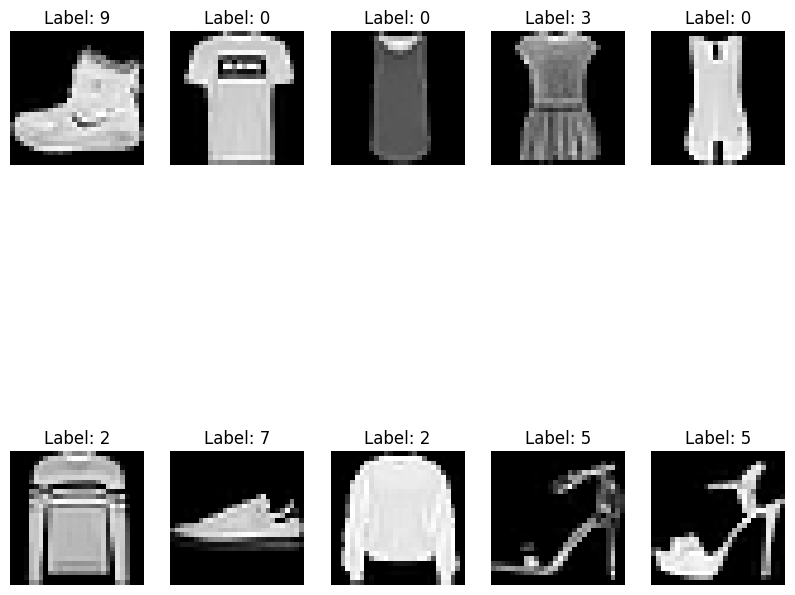

In [18]:






plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


In [20]:

X_train=X_train/255.0
X_test=X_test/255.0

In [21]:

X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

In [22]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [23]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [24]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [26]:
history=model.fit(X_train,y_train,epochs=10,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5397 - loss: 1.2133 - val_accuracy: 0.7241 - val_loss: 0.7625
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.6712 - loss: 0.8743 - val_accuracy: 0.7442 - val_loss: 0.6851
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6979 - loss: 0.8050 - val_accuracy: 0.7635 - val_loss: 0.6220
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7123 - loss: 0.7591 - val_accuracy: 0.7717 - val_loss: 0.5971
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7212 - loss: 0.7365 - val_accuracy: 0.7808 - val_loss: 0.5729
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7345 - loss: 0.6989 - val_accuracy: 0.7761 - val_loss: 0.5637
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7423 - loss: 0.6777 - val_accuracy: 0.7904 - val_loss: 0.5358
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7480 - loss: 0.6631 

In [27]:
test_loss,test___accuracy=model.evaluate(X_test,y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test___accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8049 - loss: 0.5009
Test Loss: 0.5009318590164185
Test Accuracy: 0.8048999905586243


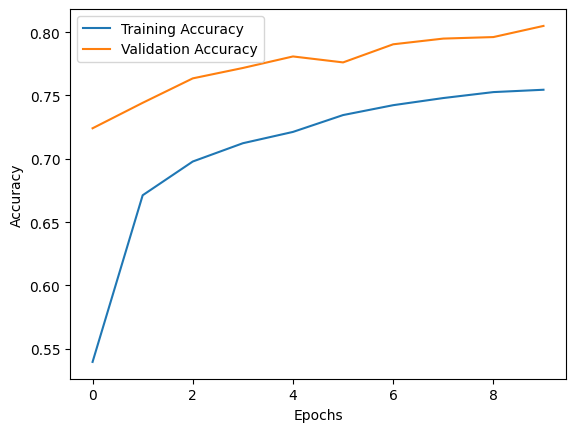

In [28]:

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
#

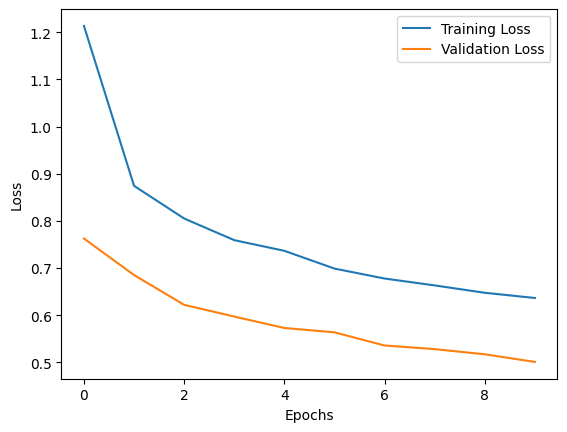

In [29]:

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


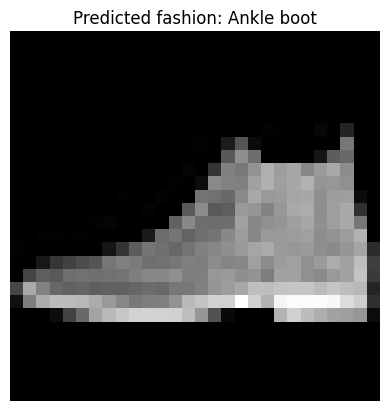

In [30]:


sample = X_test[0]
prediction = model.predict(sample.reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)

# Define Fashion MNIST class names (if not already defined in global scope)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
predicted_fashion_name = class_names[predicted_label]

plt.imshow(sample.reshape(28, 28), cmap='gray')
plt.title(f"Predicted fashion: {predicted_fashion_name}")
plt.axis('off')
plt.show()

Saving screenshot-2026-06-04_10-30-11.png to screenshot-2026-06-04_10-30-11.png


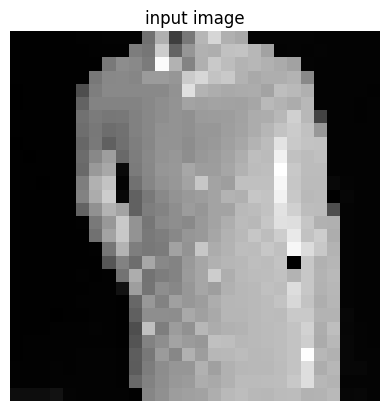

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Fashion Item: Shirt
Predicted Probability: 100.0 %


In [31]:


from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2

# Define Fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

uploaded = files.upload()
img_path=list(uploaded.keys())[0]
img=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
img=cv2.resize(img,(28,28))
img=255-img
img=img/255.0
plt.imshow(img,cmap='gray')
plt.title("input image")
plt.axis('off')
plt.show()
img=img.reshape(1,28,28,1)
prediction=model.predict(img)
predicted_label = np.argmax(prediction)
predicted_fashion_name = class_names[predicted_label]
print(f"Predicted Fashion Item: {predicted_fashion_name}")
print("Predicted Probability:",np.max(prediction)*100,"%")